In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import torch
import matplotlib.pyplot as plt
from geodesic_toolbox import *
from functools import partial
from sklearn.datasets import make_swiss_roll
from utils import *
from scipy.special import factorial
from einops import rearrange
import pandas as pd
import seaborn as sns

# Data setup

In [2]:
device = "cpu"

In [3]:
def get_bounds(embeddings: torch.Tensor, margin: float = 0.0) -> torch.Tensor:
    """
    Compute the bounds of the embeddings.

    Parameters:
    ----------
    embeddings : torch.Tensor (n_points, 2)
        The embeddings of the points.
    margin : float
        Margin scaling factor to add to the bounds. (default is 0)
        This is useful to avoid points being too close to the edges of the plot.

    Returns:
    -------
    torch.Tensor (4,)
        [min_x, max_x, min_y, max_y], the bounds of the embeddings.
    """
    min_x, max_x = embeddings[:, 0].min(), embeddings[:, 0].max()
    min_y, max_y = embeddings[:, 1].min(), embeddings[:, 1].max()
    # Add margin to the bounds
    min_x -= margin * (max_x - min_x)
    max_x += margin * (max_x - min_x)
    min_y -= margin * (max_y - min_y)
    max_y += margin * (max_y - min_y)
    # Ensure the bounds are in the correct order
    min_x, max_x = min(min_x, max_x), max(min_x, max_x)
    min_y, max_y = min(min_y, max_y), max(min_y, max_y)
    # Create a tensor with the bounds
    bounds = [min_x, max_x, min_y, max_y]
    bounds = torch.tensor(bounds)
    return bounds


def get_x_plt(resolution: int, bounds: tuple = (-2, 2, -2, 2)):
    x = np.linspace(bounds[0], bounds[1], resolution)
    y = np.linspace(bounds[2], bounds[3], resolution)
    xx, yy = np.meshgrid(x, y)
    X_plt = np.stack([xx.flatten(), yy.flatten()], axis=1)
    return torch.from_numpy(X_plt).float().to(device)


In [4]:
def sample_uniform(n_samples: int, bounds: tuple = (-2, 2, -2, 2)):
    x = np.random.uniform(bounds[0], bounds[1], n_samples)
    y = np.random.uniform(bounds[2], bounds[3], n_samples)
    samples = np.stack([x, y], axis=1)
    return torch.from_numpy(samples).float().to(device)

In [5]:
class RoundOmega(torch.nn.Module):
    def __init__(self, cometric: CoMetric, freq: float = 1.0):
        super().__init__()
        self.cometric = cometric
        self.freq = freq

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        omega = z.clone()
        omega[:, 0] = -self.freq * z[:, 1]
        omega[:, 1] = self.freq * z[:, 0]
        norm_omega = self.cometric.cometric(z, omega)
        omega = omega / (norm_omega.unsqueeze(1) + 1e-8)  # Avoid division by zero
        return omega




In [6]:
N = 3000
X = sample_uniform(N, bounds=(-2, 2, -2, 2))
X = X.to(torch.float).to(device)
bounds = get_bounds(X, margin=0.2)


In [7]:
# base_cometric = CentroidsCometric(X, IdentityCoMetric()(X),kappa=1.0).to(device)
base_cometric = IdentityCoMetric().to(device)

omega_true = RoundOmega(base_cometric, freq=1.0)

randers_metric = RandersMetrics(
    base_cometric=base_cometric,
    omega=omega_true,
    beta=0.5
)

Computing magnification factor: 100%|██████████| 79/79 [00:00<00:00, 18410.38batch/s]


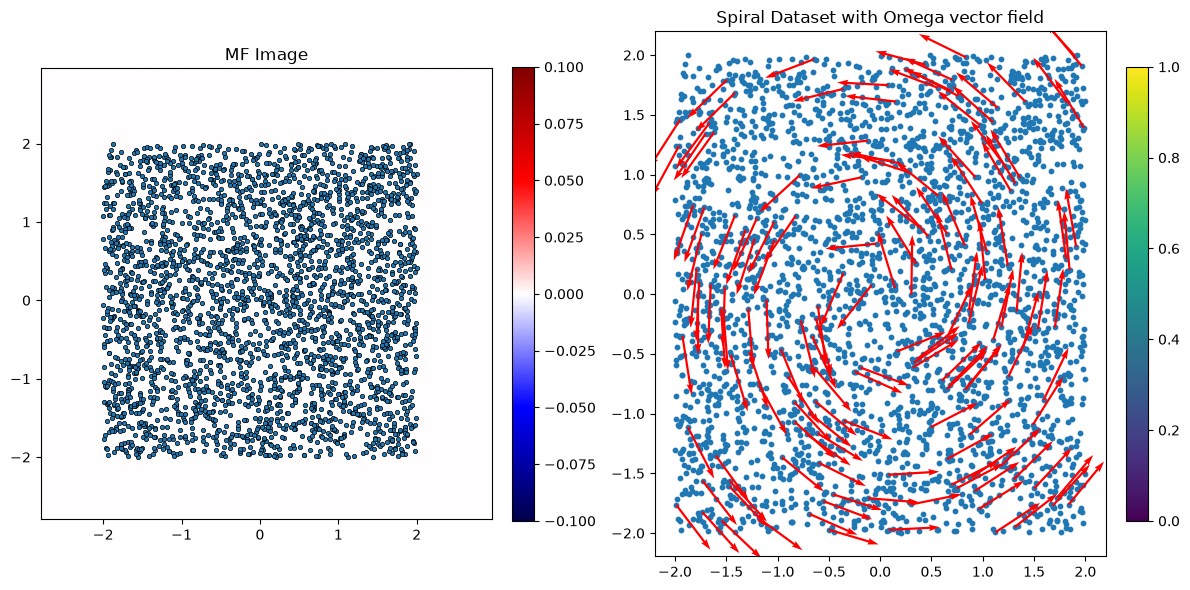

In [8]:
mf = get_mf_image(base_cometric, X, bounds)
omega_X = randers_metric.omega(X) * randers_metric.beta

fig, axes = plt.subplots(1,2, figsize=(12, 6))
im = axes[0].imshow(mf.cpu().numpy(), cmap="seismic", origin="lower", extent=bounds)
t_cbar = axes[0].scatter(
    X[:, 0].cpu(), X[:, 1].cpu(), s=10, edgecolor="k", linewidth=0.5
)
axes[0].set_title("MF Image")
axes[1].scatter(X[:, 0].cpu(), X[:, 1].cpu(), s=10)
skip = 20  # Adjust this value to change the density of the quiver plot
axes[1].quiver(X[::skip, 0].cpu(), X[::skip, 1].cpu(), omega_X[::skip, 0].cpu(), omega_X[::skip, 1].cpu(), color='red', scale=1, angles='xy',scale_units='xy')
axes[1].set_title("Spiral Dataset with Omega vector field")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(t_cbar, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.tight_layout()
plt.show()

# Construct operators

In [9]:
# Get the edges of a KNN graph
from sklearn.neighbors import kneighbors_graph

graph = kneighbors_graph(X.detach().cpu().numpy(), n_neighbors=10, mode='distance', include_self=False)
# Retrieve al the pairs of edges from the graph
edges = np.array(graph.nonzero()).T
print(f"Found {edges.shape[0]} edges in the KNN graph.")
dst_edges = construct_distance_matrix(X, edges, randers_metric)

Found 30000 edges in the KNN graph.


100%|██████████| 300/300 [02:46<00:00,  1.80it/s]


In [21]:
THETA = 0

dst_mat = torch.zeros((X.shape[0], X.shape[0]), device=X.device, dtype=X.dtype)
dst_mat[edges[:, 0], edges[:, 1]] = dst_edges
epsilon = find_espilon(dst_mat)*2
W = torch.zeros_like(dst_mat)

# Laplacian kernel
# W[edges[:, 0], edges[:, 1]] = torch.exp(-dst_mat[edges[:, 0], edges[:, 1]] / epsilon)
# mu_0 = factorial(2-1)
# mu_1 = factorial(2)

# Gaussian kernel
W[edges[:, 0], edges[:, 1]] = torch.exp(-dst_mat[edges[:, 0], edges[:, 1]]**2 / epsilon**2) 
mu_0 = 1/2 * torch.lgamma(torch.tensor(2.0)/2).exp()
mu_1 = torch.lgamma(torch.tensor(3.0)/2).exp()

W.fill_diagonal_(0)

D = torch.diag_embed(torch.sum(W, dim=1)) 
D_prime = torch.diag_embed(torch.sum(W, dim=0))
Q = (D + D_prime) / 2
Q_theta = torch.matrix_power(Q, THETA)
W_theta = torch.inverse(Q_theta) @ W @ torch.inverse(Q_theta)
D_theta = torch.diag_embed(torch.sum(W_theta, dim=1))
D_theta_prime = torch.diag_embed(torch.sum(W_theta, dim=0))
D_theta_s = (D_theta + D_theta_prime) / 2
D_theta_a = (D_theta - D_theta_prime) / 2
W_theta_s = (W_theta + W_theta.T) / 2
W_theta_a = (W_theta - W_theta.T) / 2

Id = torch.eye(W_theta.shape[0]).to(W_theta.device).to(W_theta.dtype)
P_theta_s = torch.inverse(D_theta_s) @ W_theta_s - Id
P_theta_a = torch.inverse(D_theta_s) @ (W_theta_a - D_theta_a)

L_theta_s = 1 / epsilon**2 * P_theta_s
L_theta_a = 1 / epsilon * P_theta_a

In [22]:
print("N =", dst_mat.shape[0])
print("nonzero distances =", (dst_mat > 0).sum().item())
print("total entries =", dst_mat.numel())
print("W before masking would contain",
      (dst_mat == 0).sum().item(), "entries of weight 1")
print("max asymmetry:",
      (dst_mat - dst_mat.T).abs().max().item())
print("mean asymmetry:",
      (dst_mat - dst_mat.T).abs().mean().item())
print("W asymmetry max:",
      (W - W.T).abs().max().item())

print("W asymmetry mean:",
      (W - W.T).abs().mean().item())

N = 3000
nonzero distances = 30000
total entries = 9000000
W before masking would contain 8970000 entries of weight 1
max asymmetry: 0.3620164692401886
mean asymmetry: 0.00028912091511301696
W asymmetry max: 0.9051157832145691
W asymmetry mean: 0.0012504160404205322


In [23]:
ones = torch.ones(X.shape[0], dtype=W.dtype)

constant_test = P_theta_a @ ones

print(f"Should be zero for a constant function, i.e. P_a 1 = 0")
print("||P_a 1|| mean =", constant_test.abs().mean().item())
print("||P_a 1|| max  =", constant_test.abs().max().item())

Should be zero for a constant function, i.e. P_a 1 = 0
||P_a 1|| mean = 2.7533639368471086e-08
||P_a 1|| max  = 1.1920928955078125e-07


# Construct test functions infos

In [24]:
def bump_function(x, center, radius):
    """
    A smooth bump function that is 1 at the center and smoothly decays to 0 at the radius.

    Parameters:
    ----------
    x : torch.Tensor (B, D)
        The input points in D-dimensional space.
    center : torch.Tensor (D,)
        The center of the bump function.
    radius : float
        The radius of the bump function.
    """
    distance = torch.norm(x - center, dim=-1)
    return torch.where(distance < radius, torch.exp(-1 / (1 - (distance / radius) ** 2)), torch.zeros_like(distance))

def gaussian(x, center, sigma):
    """
    A Gaussian function centered at the given point.

    Parameters:
    ----------
    x : torch.Tensor (B, D)
        The input points in D-dimensional space.
    center : torch.Tensor (D,)
        The center of the Gaussian function.
    sigma : float
        The standard deviation of the Gaussian function.
    """
    distance_squared = torch.sum((x - center) ** 2, dim=-1)
    return torch.exp(-distance_squared / (2 * sigma ** 2))

def random_sin(X):
    """
    A random sine function for testing purposes.

    Parameters:
    ----------
    X : torch.Tensor (B, D)
        The input points in D-dimensional space.
    """
    phase = torch.rand(1) * 2 * np.pi
    frequency = torch.rand(1) * 5 + 1  # Random frequency between 1 and 6
    return torch.sin(frequency * X + phase).sum(dim=-1)

K_ = X.shape[0]  # Number of test functions, one for each point in X
radius_list = [0.01, 0.1, 0.2, 0.5]
# radius_list = [0.1]
K = len(radius_list)*K_

f_values = []
Lf_values = []
f_grad_values = []

for radius in radius_list:
    f_values_radius = torch.zeros((K_, X.shape[0]))
    Lf_values_radius = torch.zeros((K_, X.shape[0]))
    f_grad_values_radius = torch.zeros((K_, X.shape[0], X.shape[1]))
    X = X.requires_grad_()
    for i in range(K_):
        center = X[i].detach()  # (D,)
        # f_ = bump_function(X, center=center.detach(), radius=radius)  # (N,)
        f_ = gaussian(X, center=center.detach(), sigma=radius)  # (N,)
        # f_ = random_sin(X) # (N,)
        f_grad_ = torch.autograd.grad(f_.sum(), X, create_graph=True)[0]  # (N, D)
        
        f_values_radius[i] = f_
        f_grad_values_radius[i] = f_grad_
        Lf_values_radius[i] = L_theta_a @ f_  # (N,)

    f_values.append(f_values_radius.detach())
    Lf_values.append(Lf_values_radius.detach())
    f_grad_values.append(f_grad_values_radius.detach())

f_values = torch.cat(f_values, dim=0)  # (K, N)
Lf_values = torch.cat(Lf_values, dim=0)  # (K, N)
f_grad_values = torch.cat(f_grad_values, dim=0)  # (K, N, D)

print(f"shapes : {f_values.shape}, {Lf_values.shape}, {f_grad_values.shape}")

# Check no problem with gradients
assert torch.all(torch.isfinite(f_grad_values)), "f_grad_values contains NaN or Inf"
assert torch.all(torch.isfinite(Lf_values)), "Lf_values contains NaN or Inf"

shapes : torch.Size([12000, 3000]), torch.Size([12000, 3000]), torch.Size([12000, 3000, 2])


# Verify operator correcteness

In [25]:
def b_to_v(b_val, A_inv_val):
    """
    Transform the vector b to v using the cometric A_inv.

    Parameters:
    ----------
    b_val : torch.Tensor (B, d)
        The vector b in the tangent space.
    A_inv_val : torch.Tensor (B, d, d) or (B, d)
        The inverse metric tensor A_inv at the point, which can be either a full matrix or a diagonal representation.   

    Returns:
    -------
    v_val : torch.Tensor (B, d)
        The vector v in the tangent space, computed from b and A_inv.
    """
    if A_inv_val.ndim == 3:  # Full matrix case
        Ab = torch.einsum("bij,bj->bi", A_inv_val, b_val)
    elif A_inv_val.ndim == 2:  # Diagonal case
        Ab = A_inv_val * b_val
    else:
        raise ValueError("A_inv_val must be either a 2D or 3D tensor.")

    b_norm_sqr = torch.einsum("bi,bi->b", b_val, Ab)
    denom = 1 - b_norm_sqr
    v_val = Ab / denom.unsqueeze(-1)
    return v_val

def v_to_b(v_val, A_val):
    """
    Revert the transformation from v to b using the cometric A.
    
    Parameters:
    ----------
    v_val : torch.Tensor (B, d)
        The vector v in the tangent space.
    A_val : torch.Tensor (B, d, d) or (B, d)
        The metric tensor A at the point, which can be either a full matrix or a diagonal representation.

    Returns:
    -------
    b_val : torch.Tensor (B, d)
        The vector b in the tangent space, computed from v and A.
    """
    if A_val.ndim == 3:  # Full matrix case
        Av = torch.einsum("bij,bj->bi", A_val, v_val)
    elif A_val.ndim == 2:  # Diagonal case
        Av = A_val * v_val
    else:
        raise ValueError("A_val must be either a 2D or 3D tensor.")

    v_norm_sqr = torch.einsum("bi,bi->b", v_val, Av)
    denom = 1 + (1 + 4 * v_norm_sqr).sqrt()
    b_val = 2 * Av / denom.unsqueeze(-1)
    return b_val

In [26]:
m = X.shape[1]
c_km = - mu_1 / mu_0 * (m+1)/m

b_true = randers_metric.omega(X) * randers_metric.beta
v_true = b_to_v(b_true, base_cometric.cometric_tensor(X))

tensor(22.4095, grad_fn=<MeanBackward0>) tensor(24.3897, grad_fn=<MedianBackward0>) tensor(133.7818, grad_fn=<MaxBackward1>) tensor(0.7635, grad_fn=<MinBackward1>)


<Axes: ylabel='Count'>

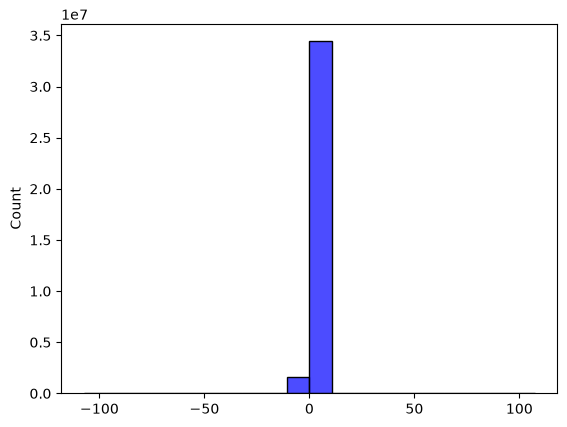

In [27]:
true_rhs = c_km * torch.einsum('n d, k n d -> k n', v_true, f_grad_values)

delta_rhs = true_rhs - Lf_values
delta_rhs_norm = torch.norm(delta_rhs, dim=1)
print(delta_rhs_norm.mean(),delta_rhs_norm.median(), delta_rhs_norm.max(), delta_rhs_norm.min())

sns.histplot(delta_rhs.flatten().cpu().detach().numpy(), bins=20, color='blue', alpha=0.7)


In [28]:
f_x = X[:, 0]
f_y = X[:, 1]

Lax = L_theta_a @ f_x
Lay = L_theta_a @ f_y

true_x = c_km * v_true[:, 0]
true_y = c_km * v_true[:, 1]

print("x mean abs error:",
      (Lax - true_x).abs().mean().item())
print("x max abs error:",
      (Lax - true_x).abs().max().item())

print("y mean abs error:",
      (Lay - true_y).abs().mean().item())
print("y max abs error:",
      (Lay - true_y).abs().max().item())

x mean abs error: 0.9389599561691284
x max abs error: 1.6701610088348389
y mean abs error: 0.9876245856285095
y max abs error: 1.701615333557129


# Exact estimation of b

In [29]:


def solve_lstsq(f_grad_values: torch.Tensor, Lf_values: torch.Tensor, c_km: float):
    """
    Solves the separable least squares problem:
        min_v sum_{k,i} |Lf_k(x_i) - c_km <v(x_i), grad f_k(x_i)>|^2
    independently at each spatial point x_i.
    
    Parameters:
    ----------
    f_grad_values : torch.Tensor (K, N, d)
        The gradients of the test functions, where K is the number of test functions, N is the number of data points, and d is the dimension of the space.
    Lf_values : torch.Tensor (K, N)
        The values of the operator applied to the test functions, where K is the number of test functions and N is the number of data points.
    c_km : float
        A scaling constant for the least squares problem.

    Returns:
    -------
    v_est : torch.Tensor (N, d)
        The estimated vector field v at each data point, where N is the number of data points and d is the dimension of the space.
    """
    K, N, d = f_grad_values.shape

    if Lf_values.shape != (K, N):
        raise ValueError(
            f"Expected Lf_values to have shape {(K, N)}, "
            f"got {Lf_values.shape}"
        )

    # Rearrange to have one least-squares system A[i] for every x_i.
    A = c_km * rearrange(f_grad_values,"k n d -> n k d")
    b = rearrange(Lf_values,"k n -> n k 1",)

    v_est = torch.linalg.lstsq(A, b).solution
    v_est = rearrange(v_est, "n d 1 -> n d")

    return v_est

In [30]:
G = f_grad_values.permute(1, 0, 2)  # N x K x m

GTG = torch.einsum("nkm,nkl->nml", G, G)

eigvals = torch.linalg.eigvalsh(GTG)

print("minimum eigenvalue:", eigvals[:, 0].min())
print("median minimum eigenvalue:", eigvals[:, 0].median())
print("mean minimum eigenvalue:", eigvals[:, 0].mean())
print("maximum eigenvalue:", eigvals[:, -1].max())

minimum eigenvalue: tensor(116.8938)
median minimum eigenvalue: tensor(765.8404)
mean minimum eigenvalue: tensor(758.5427)
maximum eigenvalue: tensor(7747.8140)


In [31]:
# Solve the problem
m = X.shape[1]
c_km = - mu_1 / mu_0 * (m+1)/m
v_hat = solve_lstsq(f_grad_values, Lf_values, c_km)
b_hat = v_to_b(v_hat, base_cometric.metric_tensor(X))

b_true = randers_metric.omega(X) * randers_metric.beta
v_true = b_to_v(b_true, base_cometric.cometric_tensor(X))

In [32]:
b_hat.norm(dim=1)

tensor([0.0260, 0.0859, 0.0520,  ..., 0.1191, 0.1339, 0.0647])

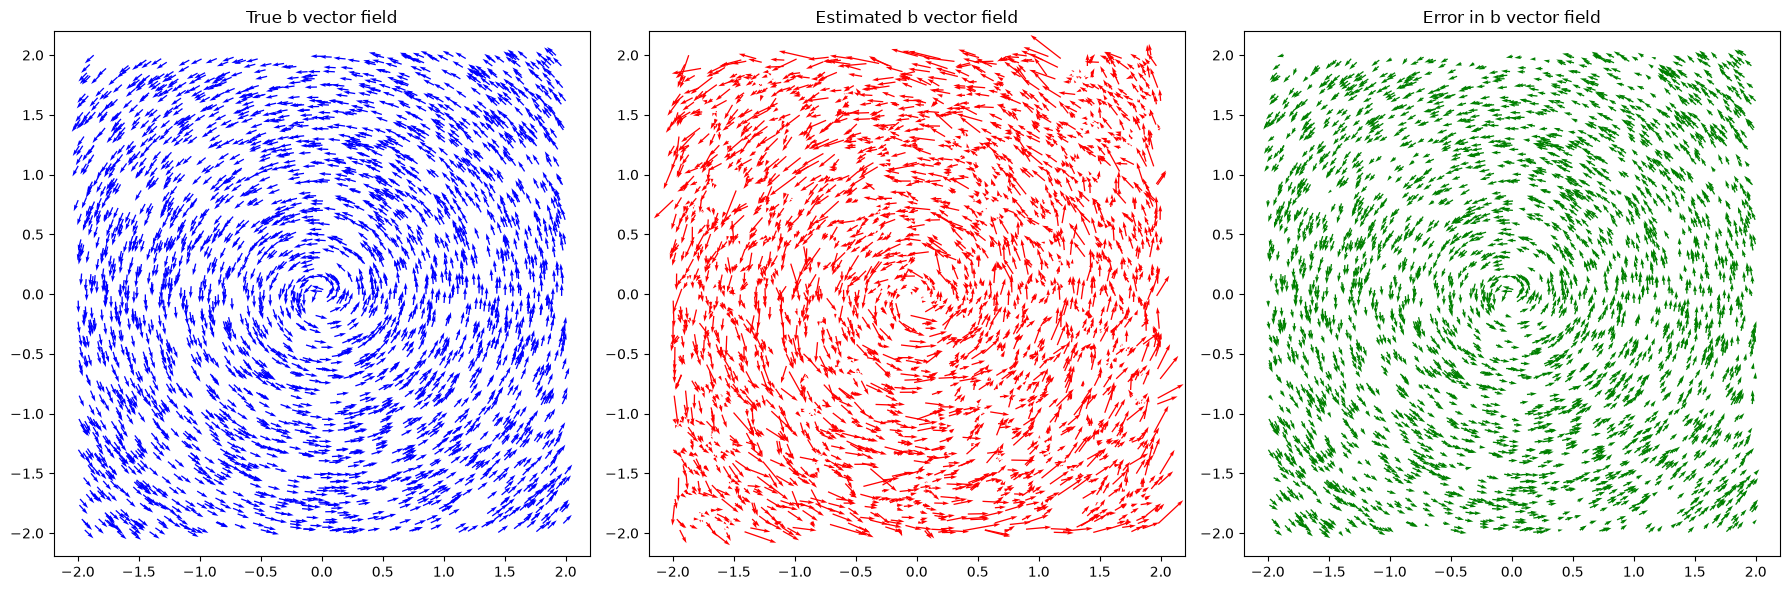

In [33]:
# Display the results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].quiver(
    X[:, 0].detach().cpu(), 
    X[:, 1].detach().cpu(),
    b_true[:, 0].detach().cpu(),
    b_true[:, 1].detach().cpu(),
    color='blue', scale=5, angles='xy',scale_units='xy'
)
axes[0].set_title("True b vector field")
axes[1].quiver(
    X[:, 0].detach().cpu(), 
    X[:, 1].detach().cpu(),
    b_hat[:, 0].detach().cpu(),
    b_hat[:, 1].detach().cpu(),
    color='red', scale=1, angles='xy',scale_units='xy'
)
axes[1].set_title("Estimated b vector field")
axes[2].quiver(
    X[:, 0].detach().cpu(), 
    X[:, 1].detach().cpu(),
    (b_true - b_hat)[:, 0].detach().cpu(),
    (b_true - b_hat)[:, 1].detach().cpu(),
    color='green', scale=5, angles='xy',scale_units='xy'
)
axes[2].set_title("Error in b vector field")
plt.tight_layout()

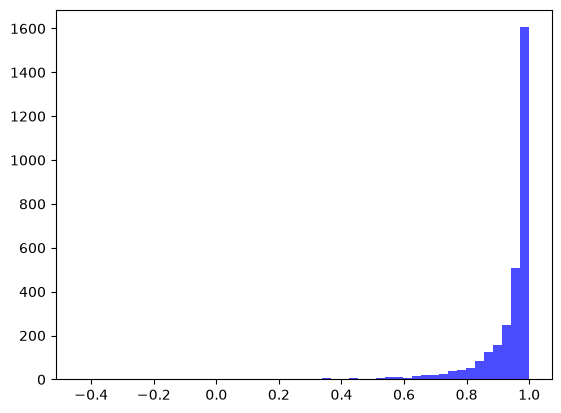

In [34]:
cosim = torch.nn.CosineSimilarity(dim=1, eps=1e-6)
cosine_similarity = cosim(b_true, b_hat)
cosine_similarity
plt.hist(cosine_similarity.cpu().detach().numpy(), bins=50, color='blue', alpha=0.7)
plt.show()

# Deep estimation of b

In [35]:
class V_estimator(torch.nn.Module):
    def __init__(self, hidden_dims:list[int], dim:int=2):
        super().__init__()
        self.hidden_dims = hidden_dims
        self.dim = dim
        layers = []
        input_dim = dim
        for h_dim in hidden_dims:
            layers.append(torch.nn.Linear(input_dim, h_dim))
            layers.append(torch.nn.SiLU())
            input_dim = h_dim
        layers.append(torch.nn.Linear(input_dim, dim))
        self.model = torch.nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

class OmegaFromV(torch.nn.Module):
    def __init__(self, v_estimator: V_estimator, cometric: CoMetric):
        super().__init__()
        self.v_estimator = v_estimator
        self.cometric = cometric

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        v_x = self.v_estimator(x)
        v_norm = self.cometric.metric(x, v_x)
        A_x = self.cometric.metric_tensor(x)
        if self.cometric.is_diag:
            Av = torch.einsum("...i,...i->...i", A_x, v_x)
        else:
            Av = torch.einsum("...ij,...j->...i", A_x, v_x)
        denom = 1 + (1+ 4*v_norm**2).sqrt()
        omega_x = 2*Av / denom.unsqueeze(-1)
        return omega_x

In [36]:
v_model = V_estimator(hidden_dims=[64, 64], dim=2).to(device)
omega_model = OmegaFromV(v_estimator=v_model, cometric=base_cometric).to(device)
randers_model = RandersMetrics(base_cometric=base_cometric, omega=omega_model, beta=1.0).to(device)

In [37]:
optim = torch.optim.Adam(v_model.parameters(), lr=1e-3)

loss_list = []
b_size = 128
pbar = tqdm(range(1000))
for epoch in pbar:
    idx_i = torch.randint(0, X.shape[0], (b_size,), device=device)
    X_i = X[idx_i].requires_grad_(True) # (B, D)
    
    lf_i = Lf_values[:, idx_i].detach() # (K, B)
    grad_f_i = f_grad_values[:, idx_i, :].detach() # (K, B, D)
    v_x = v_model(X_i) # (B, D)
    dot_product =c_km* torch.einsum("kbd,bd->kb", grad_f_i, v_x) # (K, B)
    loss = torch.nn.functional.mse_loss(dot_product, lf_i.detach()) # (K, B)
    optim.zero_grad()
    loss.backward()
    optim.step()
    loss_list.append(loss.item())

    pbar.set_description(f"Loss: {loss.item():.4e}")

Loss: 3.3185e-03: 100%|██████████| 1000/1000 [00:19<00:00, 52.09it/s]


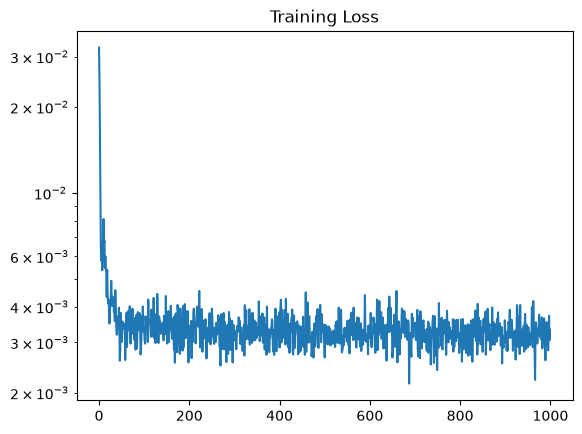

In [38]:
plt.plot(loss_list)
plt.title("Training Loss")
plt.yscale("log")

In [39]:
b_hat_deep = omega_model(X).detach()

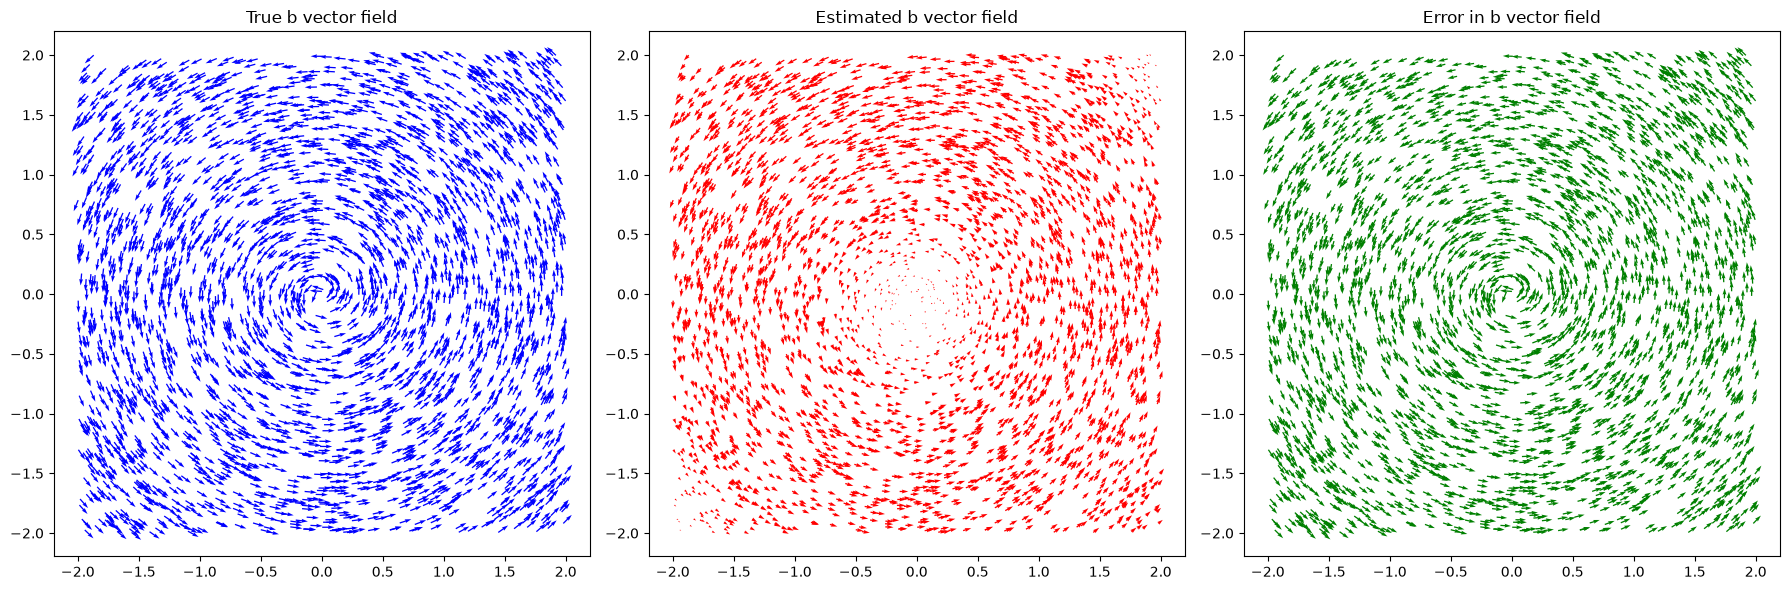

In [40]:
# Display the results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].quiver(
    X[:, 0].detach().cpu(), 
    X[:, 1].detach().cpu(),
    b_true[:, 0].detach().cpu(),
    b_true[:, 1].detach().cpu(),
    color='blue', scale=5, angles='xy',scale_units='xy'
)
axes[0].set_title("True b vector field")
axes[1].quiver(
    X[:, 0].detach().cpu(), 
    X[:, 1].detach().cpu(),
    b_hat_deep[:, 0].detach().cpu(),
    b_hat_deep[:, 1].detach().cpu(),
    color='red', scale=1, angles='xy',scale_units='xy'
)
axes[1].set_title("Estimated b vector field")
axes[2].quiver(
    X[:, 0].detach().cpu(), 
    X[:, 1].detach().cpu(),
    (b_true - b_hat_deep)[:, 0].detach().cpu(),
    (b_true - b_hat_deep)[:, 1].detach().cpu(),
    color='green', scale=5, angles='xy',scale_units='xy'
)
axes[2].set_title("Error in b vector field")
plt.tight_layout()

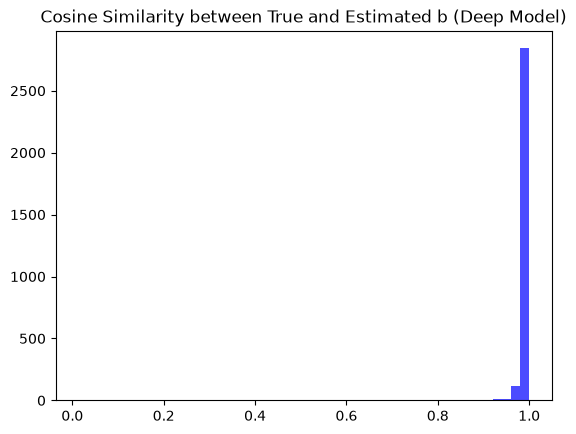

In [41]:
cosim = torch.nn.CosineSimilarity(dim=1, eps=1e-6)
cosine_similarity_deep = cosim(b_true, b_hat_deep)
plt.hist(cosine_similarity_deep.cpu().detach().numpy(), bins=50, color='blue', alpha=0.7)
plt.title("Cosine Similarity between True and Estimated b (Deep Model)")
plt.show()